In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [73]:
df = pd.read_csv("../data/processed/final.csv")

df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BNjViNW...,Hamilton,2020,PG-13,160 min,"Biography, Drama, History",8.6,The real life of one of America's foremost fou...,90.0,Thomas Kail,Lin-Manuel Miranda,Phillipa Soo,Leslie Odom Jr.,Renée Elise Goldsberry,55291,NaN
1,https://m.media-amazon.com/images/M/MV5BYWZjMj...,Gisaengchung,2019,A,132 min,"Comedy, Drama, Thriller",8.6,Greed and class discrimination threaten the ne...,96.0,Bong Joon Ho,Kang-ho Song,Lee Sun-kyun,Cho Yeo-jeong,Choi Woo-sik,552778,"53,367,844"
2,https://m.media-amazon.com/images/M/MV5BOTc2ZT...,Soorarai Pottru,2020,U,153 min,Drama,8.6,"Nedumaaran Rajangam ""Maara"" sets out to make t...",79.0,Sudha Kongara,Suriya,Madhavan,Paresh Rawal,Aparna Balamurali,54995,NaN
3,https://m.media-amazon.com/images/M/MV5BOTMwYj...,Cidade de Deus,2002,A,130 min,"Crime, Drama",8.6,"In the slums of Rio, two kids' paths diverge a...",79.0,Fernando Meirelles,Kátia Lund,Alexandre Rodrigues,Leandro Firmino,Matheus Nachtergaele,699256,"7,563,397"
4,https://m.media-amazon.com/images/M/MV5BMjlmZm...,Sen to Chihiro no kamikakushi,2001,U,125 min,"Animation, Adventure, Family",8.6,"During her family's move to the suburbs, a sul...",96.0,Hayao Miyazaki,Daveigh Chase,Suzanne Pleshette,Miyu Irino,Rumi Hiiragi,651376,"10,055,859"


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 899 entries, 0 to 898
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    899 non-null    str    
 1   Series_Title   899 non-null    str    
 2   Released_Year  899 non-null    str    
 3   Certificate    800 non-null    str    
 4   Runtime        899 non-null    str    
 5   Genre          899 non-null    str    
 6   IMDB_Rating    899 non-null    float64
 7   Overview       899 non-null    str    
 8   Meta_score     899 non-null    float64
 9   Director       899 non-null    str    
 10  Star1          899 non-null    str    
 11  Star2          899 non-null    str    
 12  Star3          899 non-null    str    
 13  Star4          899 non-null    str    
 14  No_of_Votes    899 non-null    int64  
 15  Gross          731 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 112.5 KB


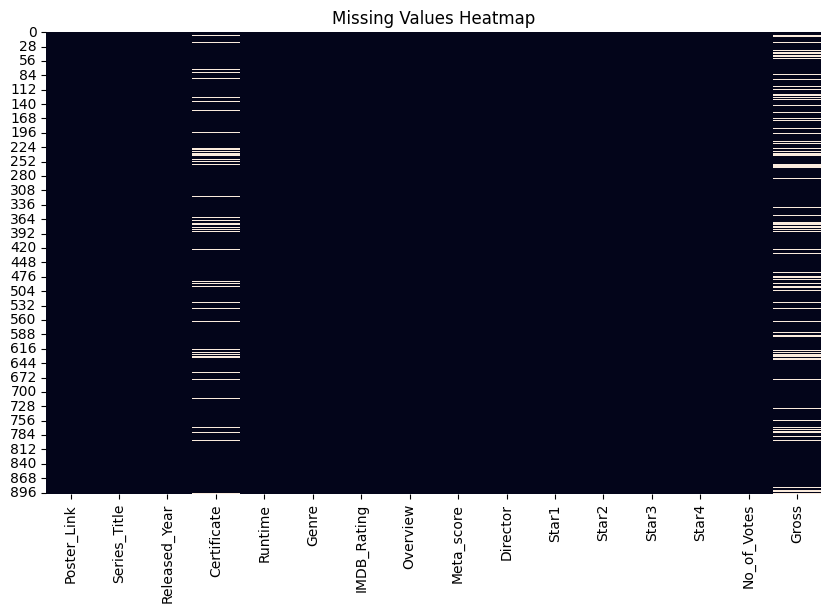

In [75]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

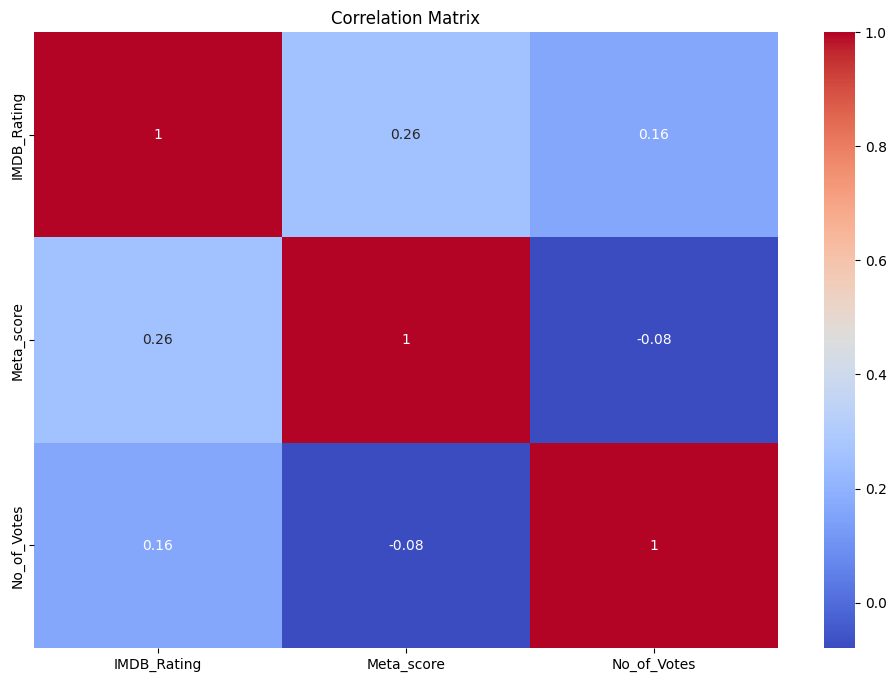

In [76]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

In [77]:
corr["IMDB_Rating"].sort_values(ascending=False)

IMDB_Rating    1.000000
Meta_score     0.256533
No_of_Votes    0.164706
Name: IMDB_Rating, dtype: float64

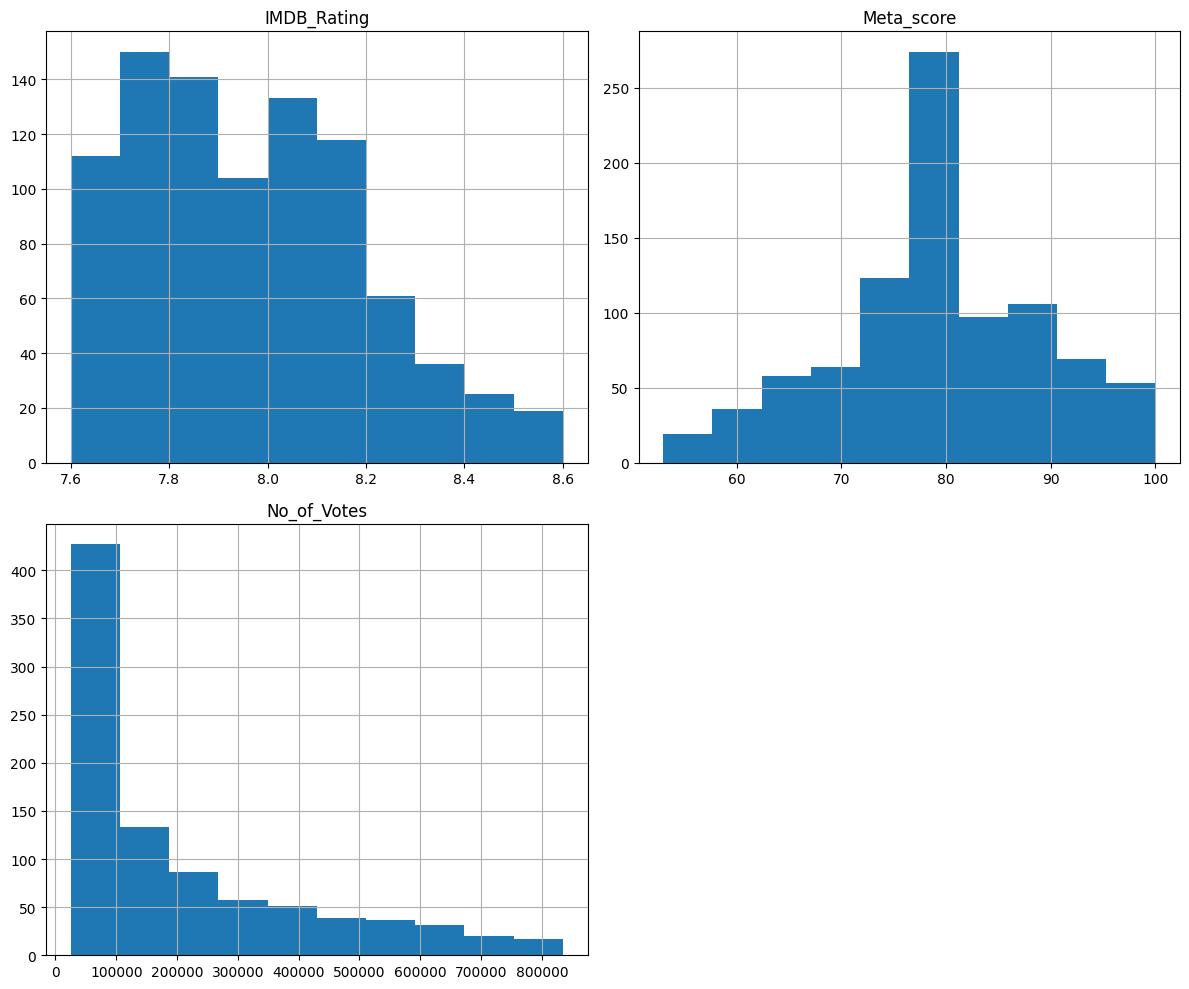

In [78]:
df.hist(figsize=(12,10))

plt.tight_layout()

plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'PG-13'),
  Text(1, 0, 'A'),
  Text(2, 0, 'U'),
  Text(3, 0, 'PG'),
  Text(4, 0, 'UA'),
  Text(5, 0, 'R'),
  Text(6, 0, 'G'),
  Text(7, 0, 'Passed'),
  Text(8, 0, 'TV-14'),
  Text(9, 0, '16'),
  Text(10, 0, 'TV-MA'),
  Text(11, 0, 'Unrated'),
  Text(12, 0, 'GP'),
  Text(13, 0, 'Approved'),
  Text(14, 0, 'TV-PG'),
  Text(15, 0, 'U/A')])

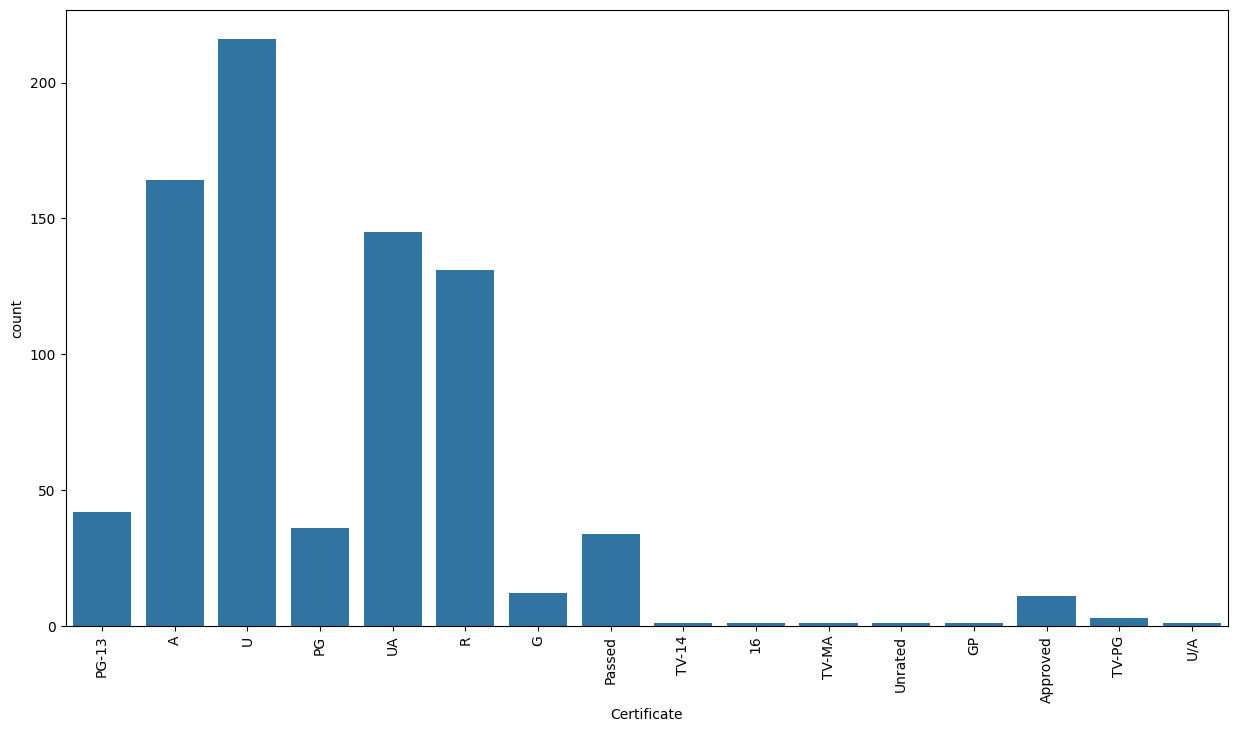

In [79]:
plt.figure(figsize=(15,8))
sns.countplot(x ='Certificate',data=df)
plt.xticks(rotation = 'vertical')

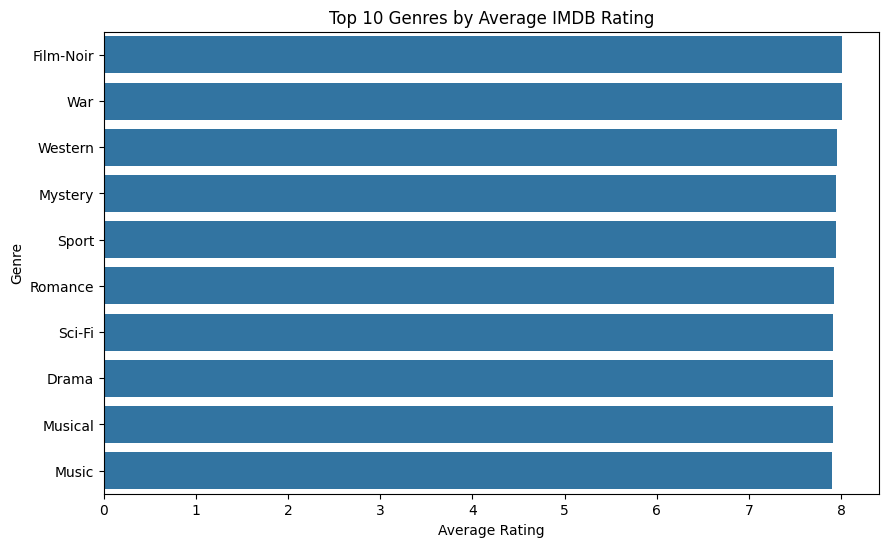

In [80]:
genre_rating = df_exploded.groupby("Genre")["IMDB_Rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_rating.values, y=genre_rating.index)

plt.title("Top 10 Genres by Average IMDB Rating")
plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.show()

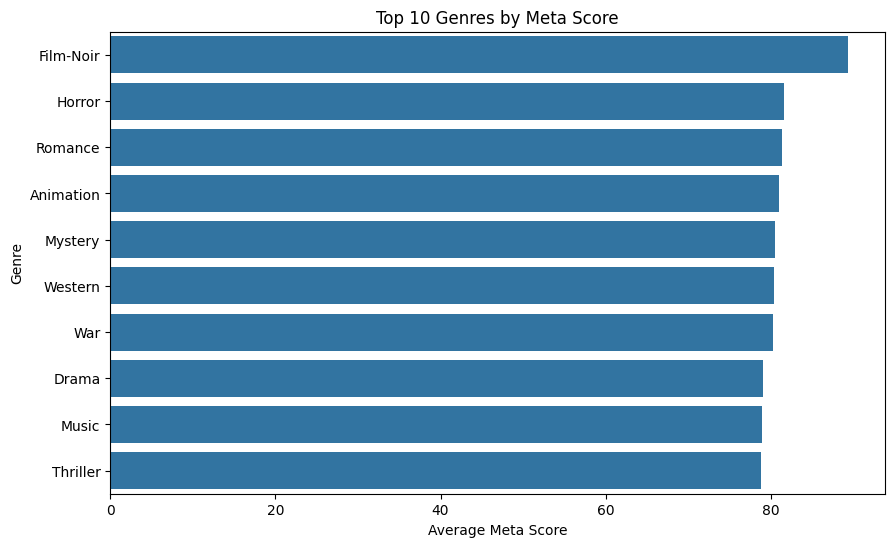

In [81]:
genre_meta = df_exploded.groupby("Genre")["Meta_score"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_meta.values, y=genre_meta.index)

plt.title("Top 10 Genres by Meta Score")
plt.xlabel("Average Meta Score")
plt.ylabel("Genre")

plt.show()

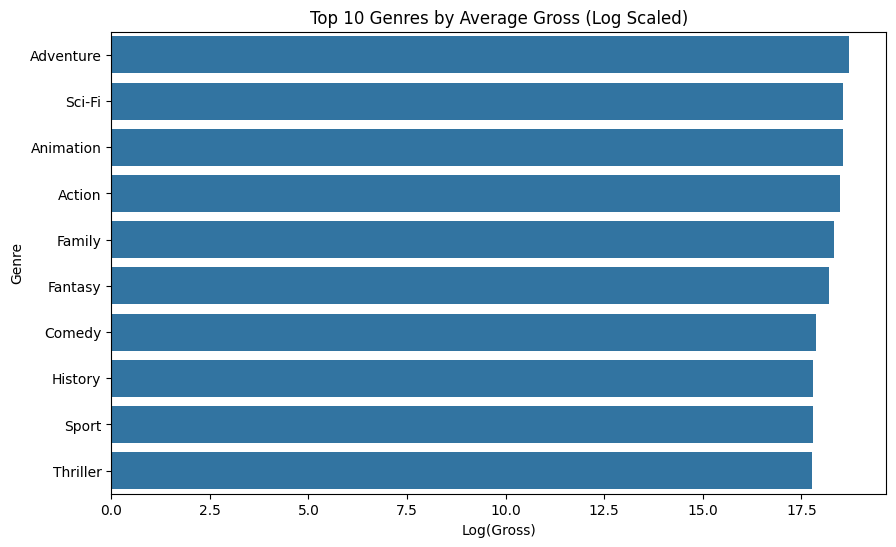

In [82]:
genre_gross = df_exploded.groupby("Genre")["Gross"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=np.log1p(genre_gross.values), y=genre_gross.index)

plt.title("Top 10 Genres by Average Gross (Log Scaled)")
plt.xlabel("Log(Gross)")
plt.ylabel("Genre")

plt.show()

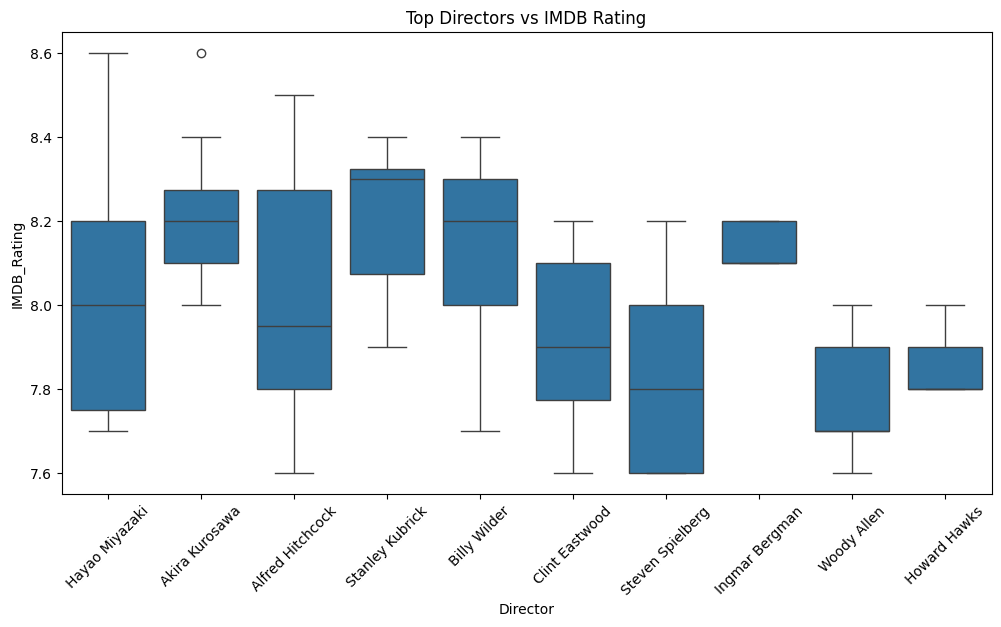

In [83]:
top_directors = df["Director"].value_counts().head(10).index

df_dir = df[df["Director"].isin(top_directors)]

plt.figure(figsize=(12,6))
sns.boxplot(x="Director", y="IMDB_Rating", data=df_dir)

plt.xticks(rotation=45)
plt.title("Top Directors vs IMDB Rating")

plt.show()

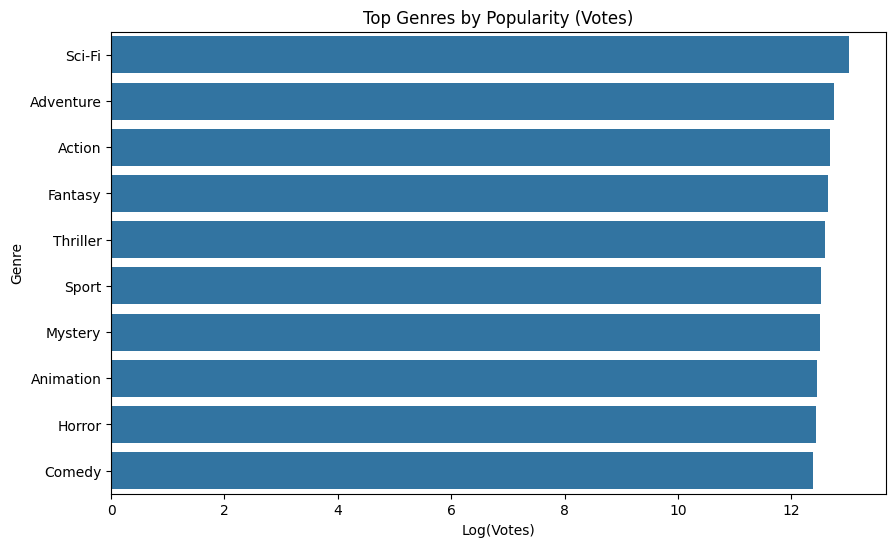

In [85]:
genre_votes = df_exploded.groupby("Genre")["No_of_Votes"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=np.log1p(genre_votes.values), y=genre_votes.index)

plt.title("Top Genres by Popularity (Votes)")
plt.xlabel("Log(Votes)")
plt.ylabel("Genre")

plt.show()